# プレイヤー間の特徴量のT検定を行う

## パス関係の定義

In [1]:
import sys
from pathlib import Path

# src ディレクトリのパスを取得して追加
src_dir = str(Path().resolve().parents[1])
if src_dir not in sys.path:
    sys.path.append(src_dir)

## データの取り出し

In [2]:
from analyzers import datamanager

data_manager = datamanager.DataManager("../processed_data")

trajectories = data_manager.get_all_trajectories()

Match Type:  odict_keys(['AB', 'BD', 'CB', 'G1', 'G2', 'G3', 'G4', 'after', 'before'])


### 検定対象のデータの決定

T検定の対象：
- （AB, after）
- （AB, before）
- （after, before）

In [3]:
from analyzers import calculator, utils

ANALYZE_MATCH_TYPES = ['AB', 'after', 'before']

all_player_names = data_manager.get_all_player_names()

analyze_match_data_ave = {}
analyze_match_data_std = {}

for player_name in all_player_names:
    player_trajectories = data_manager.get_data_by_player(player_name)

    # 特徴量を辞書に記録する
    averages = calculator.dict_average(player_trajectories)
    std_devs = calculator.dict_std_dev(player_trajectories)

    for match_type in ANALYZE_MATCH_TYPES:
        analyze_match_data_ave.setdefault(match_type, {})[player_name] = averages[match_type]
        analyze_match_data_std.setdefault(match_type, {})[player_name] = std_devs[match_type]

max_ave = utils.round_up(calculator.max_recursive(analyze_match_data_ave))
max_std = utils.round_up(calculator.max_recursive(analyze_match_data_std))

## T検定とその描画

### 組み合わせの定義

In [4]:
import itertools

all_combinations = list(itertools.combinations(ANALYZE_MATCH_TYPES, 2))
all_player_names = data_manager.get_all_player_names()

colors_dict = {
    'O1red': 'red',
    'O2blue': 'blue',
    'O3pink': 'pink',
    'D1black': 'black',
    'D2orange': 'orange',
    'D3yellow': 'yellow'
}

### 平均値に関するT検定

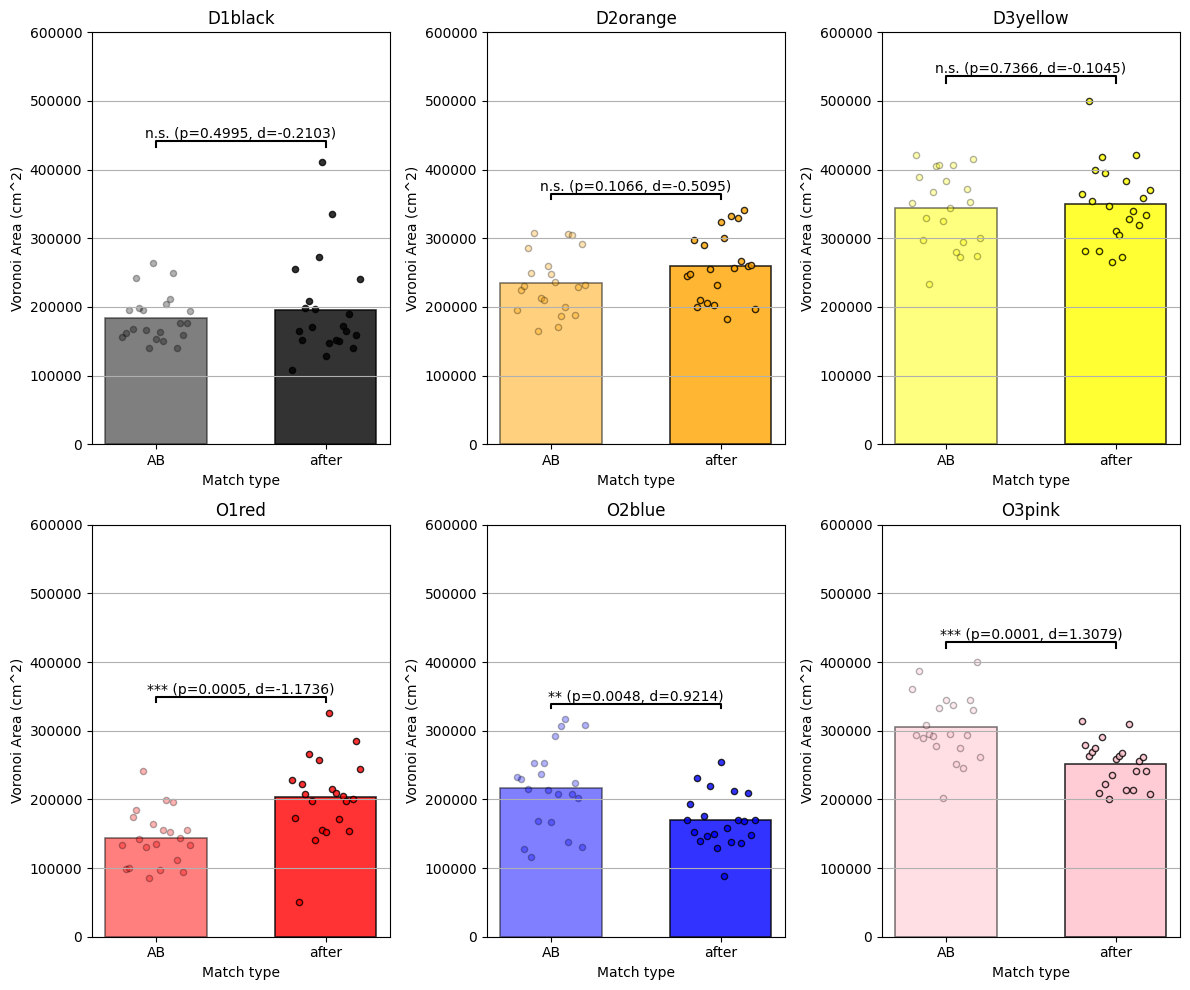

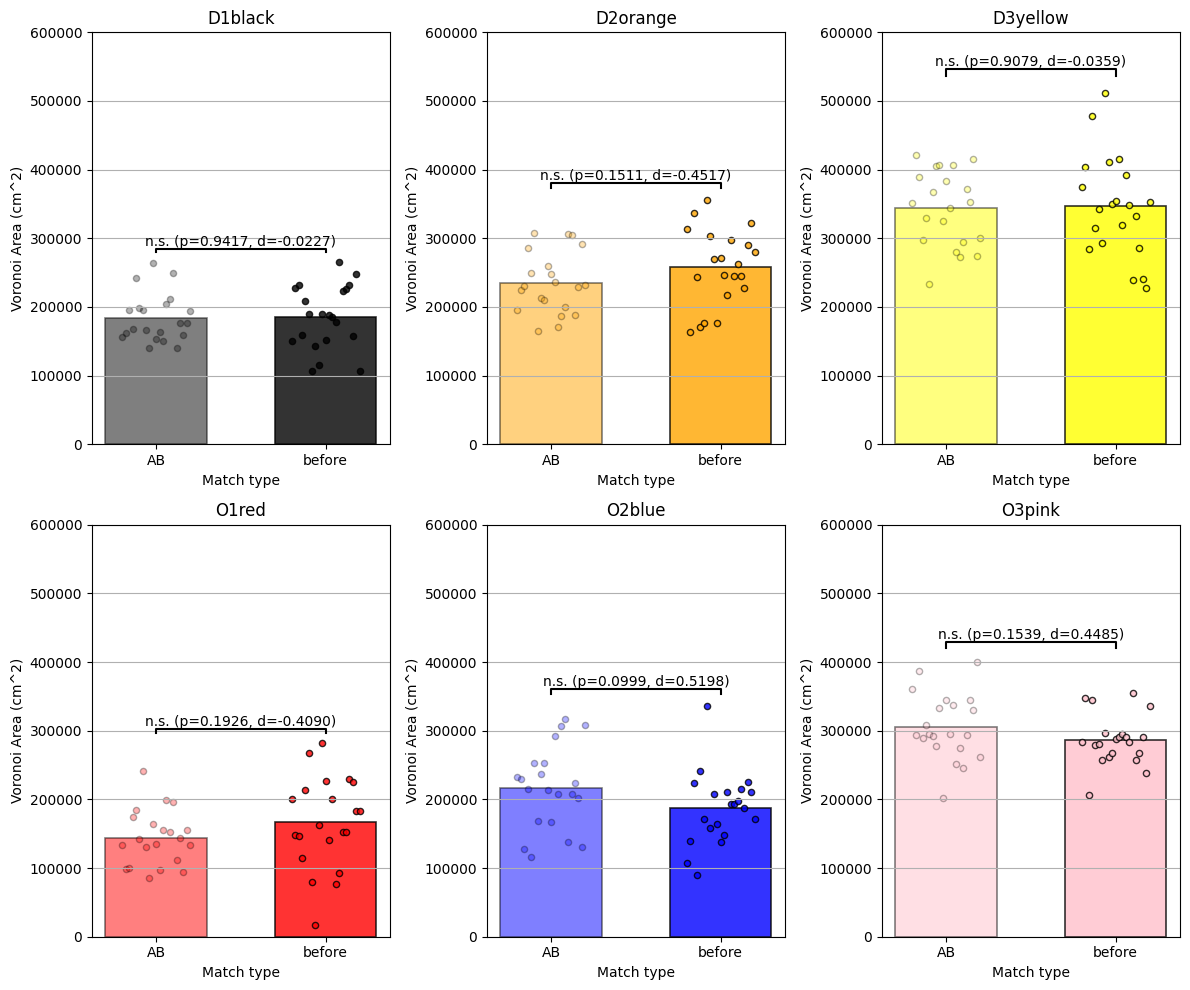

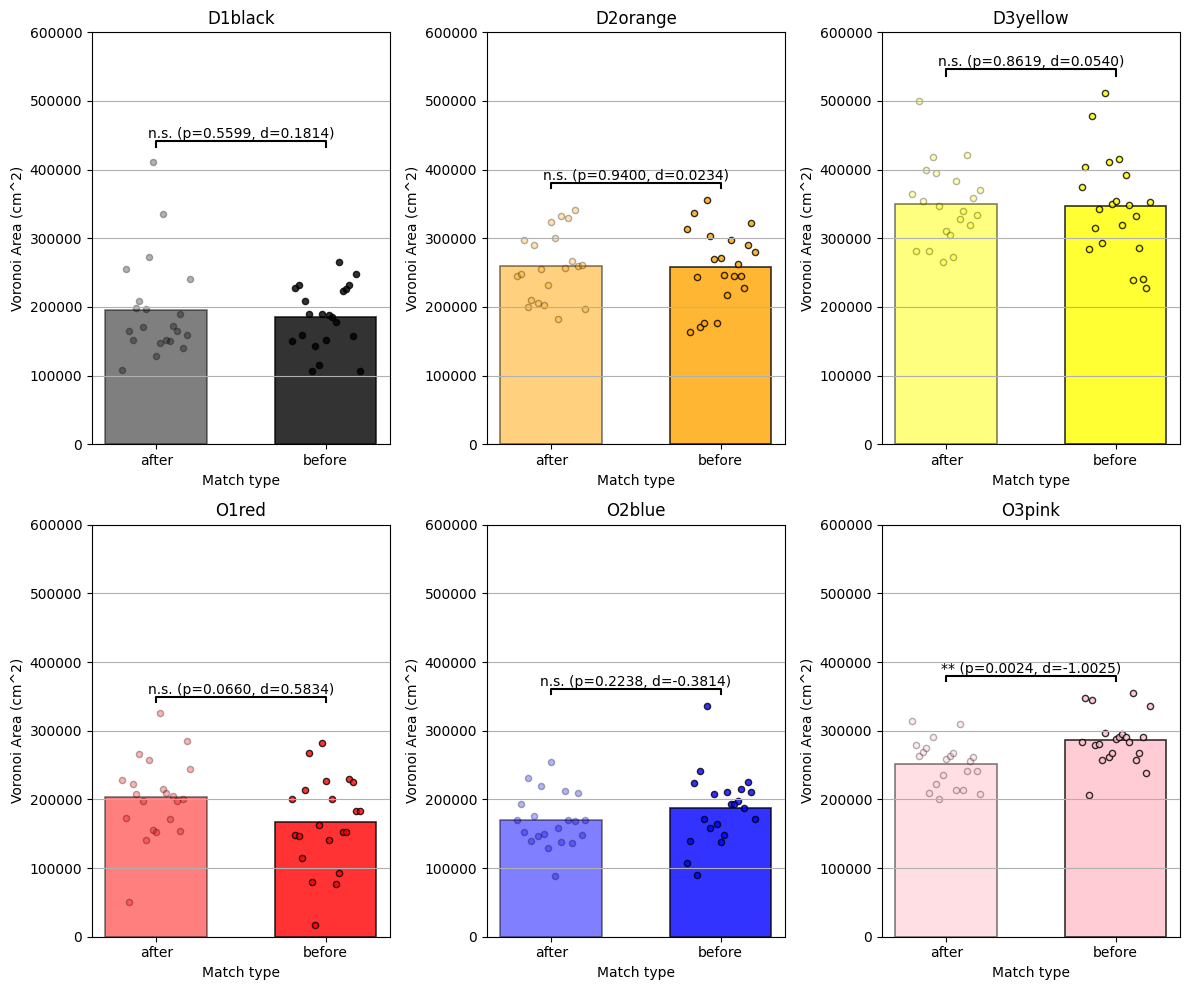

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt

from analyzers.t_test import drawer

for (match_one, match_two) in all_combinations:
    size_of_ax = (4, 5)
    num_axes = len(all_player_names)
    num_cols = 3
    num_rows = math.ceil(num_axes / num_cols)
    fig, axes = plt.subplots(
        nrows=num_rows,
        ncols=num_cols,
        figsize=(size_of_ax[0]*num_cols, size_of_ax[1]*num_rows)
    )
    axes = axes.flatten()

    match_one_data = analyze_match_data_ave[match_one]
    match_two_data = analyze_match_data_ave[match_two]

    for idx, player_name in enumerate(all_player_names):
        color = colors_dict[player_name]

        drawer.plot_t_test(
            data=[
                np.array(list(match_one_data[player_name].values())),
                np.array(list(match_two_data[player_name].values()))
            ],
            ax=axes[idx],
            labels=[match_one, match_two],
            bar_kwargs=[
                {
                    'color': color,
                    'edgecolor': 'black',
                    'linewidth': 1.2,
                    'width': 0.6,
                    'alpha': 0.5
                },
                {
                    'color': color,
                    'edgecolor': 'black',
                    'linewidth': 1.2,
                    'width': 0.6,
                    'alpha': 0.8
                }
            ],
            scatter_kwargs=[
                {
                    'color': color,
                    'edgecolor': 'black',
                    'label': player_name,
                    'alpha': 0.3,
                    's': 20
                },
                {
                    'color': color,
                    'edgecolor': 'black',
                    'label': player_name,
                    'alpha': 0.8,
                    's': 20
                }
            ]
        )
        axes[idx].set_title(player_name)
    
    plt.setp(axes, ylim=(0, max_ave))
    plt.tight_layout()

    results_dir = Path('./results')
    results_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(f'./results/average_{match_one}_{match_two}.png', bbox_inches='tight')
    plt.show()
    plt.close()

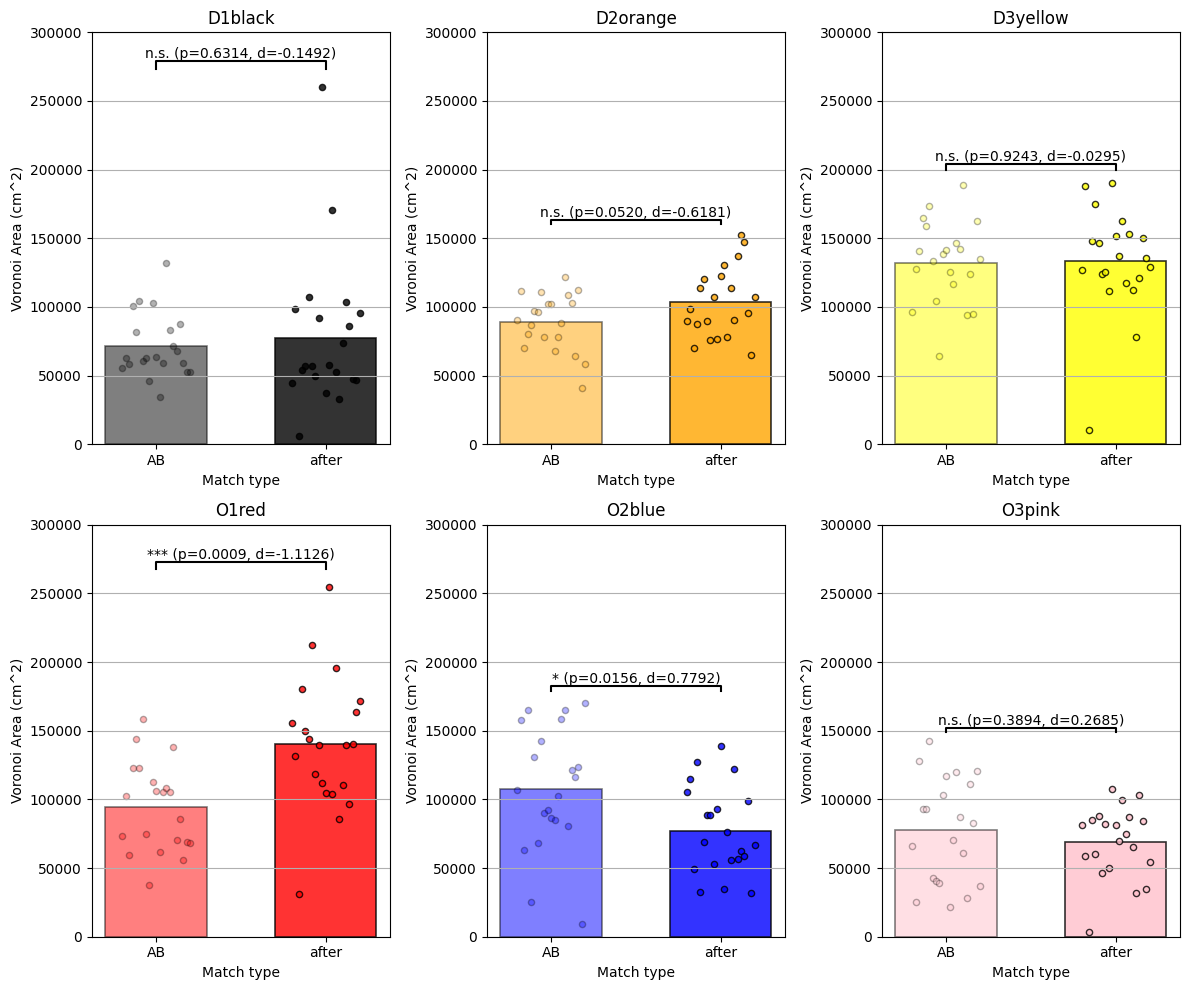

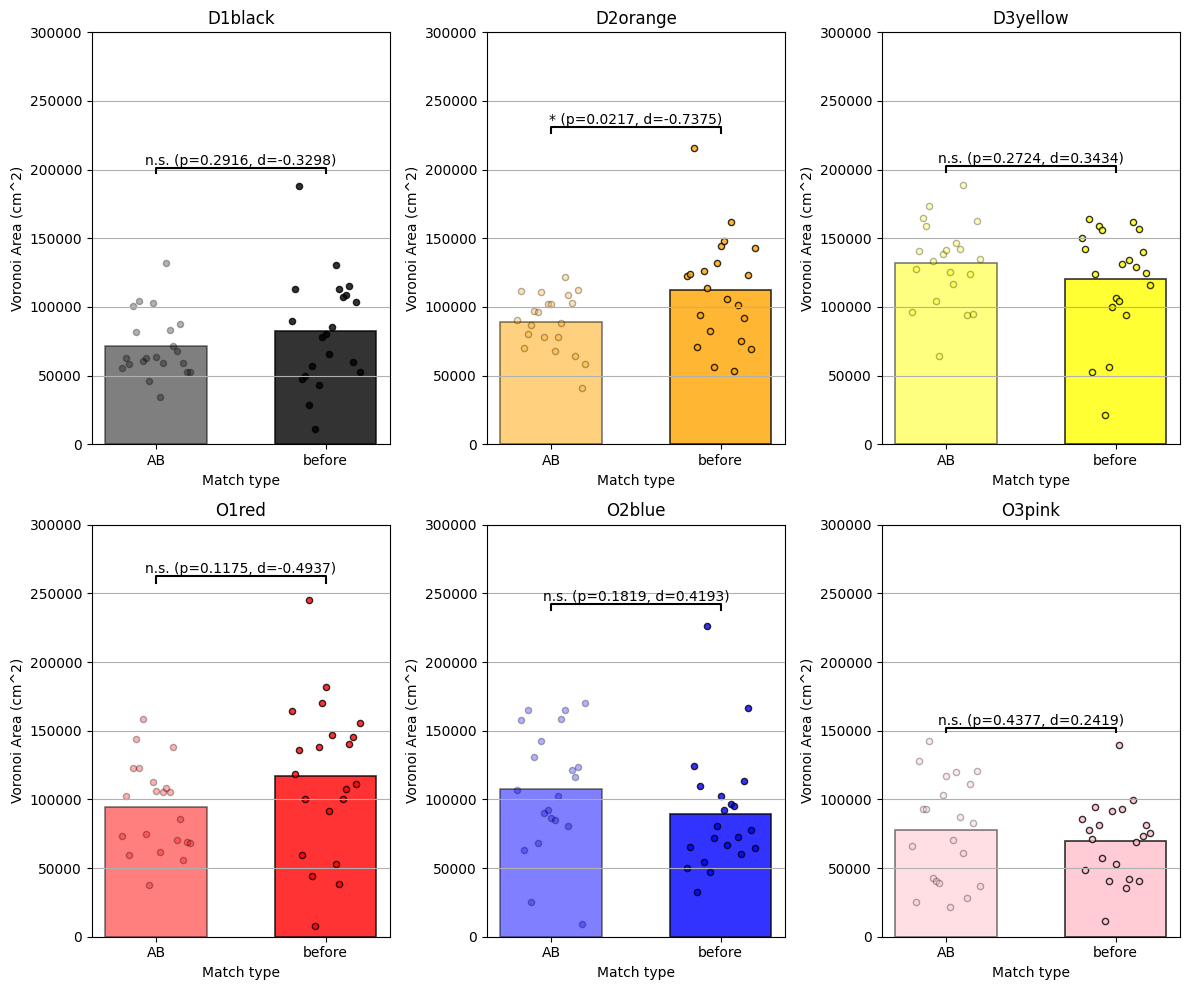

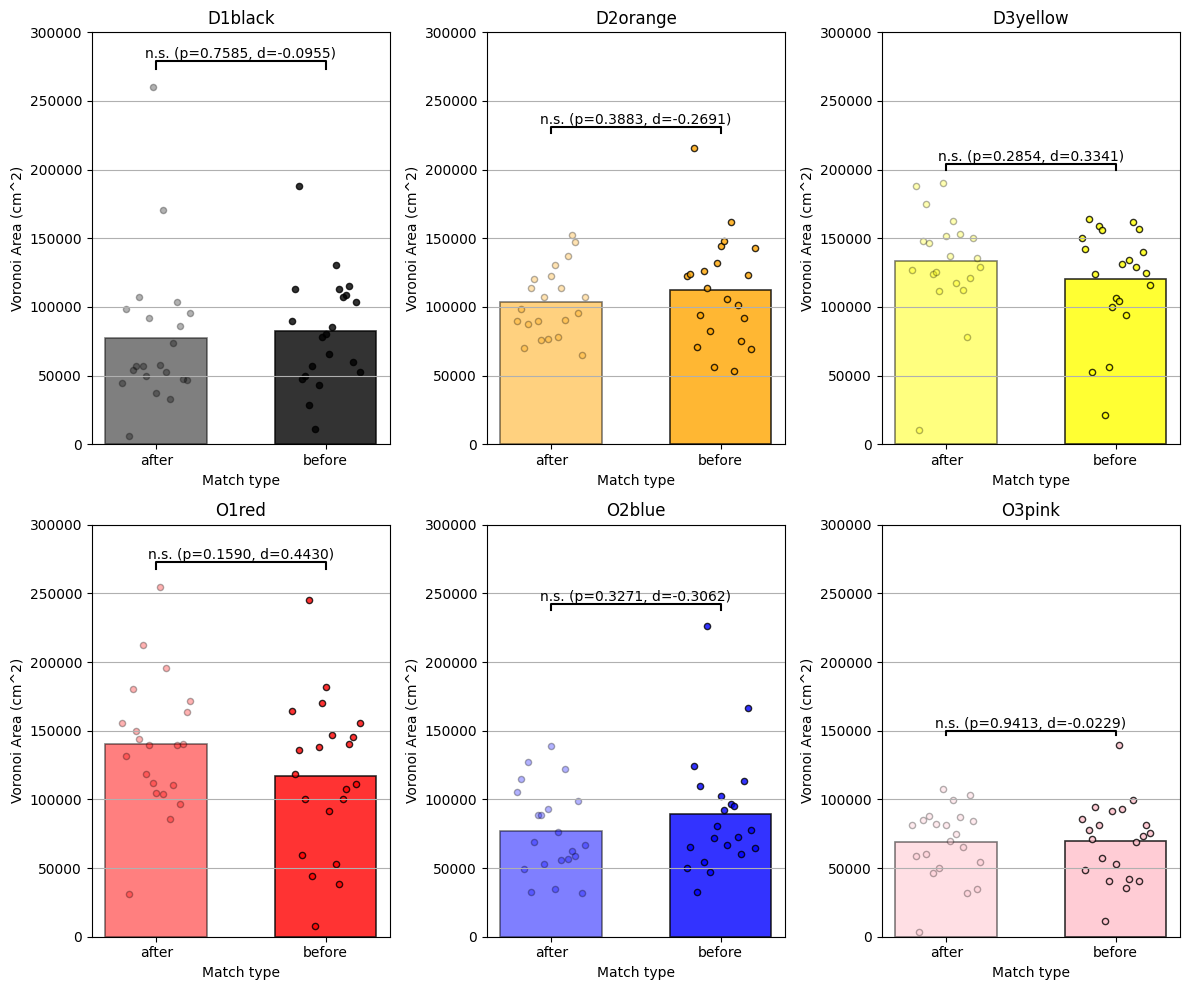

In [6]:
for (match_one, match_two) in all_combinations:
    size_of_ax = (4, 5)
    num_axes = len(all_player_names)
    num_cols = 3
    num_rows = math.ceil(num_axes / num_cols)
    fig, axes = plt.subplots(
        nrows=num_rows,
        ncols=num_cols,
        figsize=(size_of_ax[0]*num_cols, size_of_ax[1]*num_rows)
    )
    axes = axes.flatten()

    match_one_data = analyze_match_data_std[match_one]
    match_two_data = analyze_match_data_std[match_two]

    for idx, player_name in enumerate(all_player_names):
        color = colors_dict[player_name]

        drawer.plot_t_test(
            data=[
                np.array(list(match_one_data[player_name].values())),
                np.array(list(match_two_data[player_name].values()))
            ],
            ax=axes[idx],
            labels=[match_one, match_two],
            bar_kwargs=[
                {
                    'color': color,
                    'edgecolor': 'black',
                    'linewidth': 1.2,
                    'width': 0.6,
                    'alpha': 0.5
                },
                {
                    'color': color,
                    'edgecolor': 'black',
                    'linewidth': 1.2,
                    'width': 0.6,
                    'alpha': 0.8
                }
            ],
            scatter_kwargs=[
                {
                    'color': color,
                    'edgecolor': 'black',
                    'label': player_name,
                    'alpha': 0.3,
                    's': 20
                },
                {
                    'color': color,
                    'edgecolor': 'black',
                    'label': player_name,
                    'alpha': 0.8,
                    's': 20
                }
            ]
        )
        axes[idx].set_title(player_name)
    
    plt.setp(axes, ylim=(0, max_std))
    plt.tight_layout()

    results_dir = Path('./results')
    results_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(f'./results/std_devs_{match_one}_{match_two}.png', bbox_inches='tight')
    plt.show()
    plt.close()